# Sales and Demand Forecasting
### Predicting future sales using historical Superstore business data
Dataset: Sample Superstore Sales Dataset

## Imports and Configuration

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

DATA_PATH  = r'C:\Users\vinnu\Downloads\Sample - Superstore.csv'
OUTPUT_DIR = r'C:\Users\vinnu\Downloads\FUTURE_ML_01\outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Imports done')

Imports done


## Load and Explore Data

In [2]:
print('Loading data ...')
df = pd.read_csv(DATA_PATH, encoding='latin-1')

print(f'   Total records  : {len(df):,}')
print(f'   Columns        : {df.shape[1]}')
print(f'   Date range     : {df["Order Date"].min()} to {df["Order Date"].max()}')
print(f'   Total Sales    : ${df["Sales"].sum():,.2f}')
print(f'   Categories     : {df["Category"].unique().tolist()}')
print(f'   Regions        : {df["Region"].unique().tolist()}')
df.head()

Loading data ...
   Total records  : 9,994
   Columns        : 21
   Date range     : 1/1/2017 to 9/9/2017
   Total Sales    : $2,297,200.86
   Categories     : ['Furniture', 'Office Supplies', 'Technology']
   Regions        : ['South', 'West', 'Central', 'East']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Cleaning and Feature Engineering

In [3]:
# Parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  format='%m/%d/%Y')

# Time-based features
df['Year']          = df['Order Date'].dt.year
df['Month']         = df['Order Date'].dt.month
df['Quarter']       = df['Order Date'].dt.quarter
df['DayOfWeek']     = df['Order Date'].dt.dayofweek
df['DayOfYear']     = df['Order Date'].dt.dayofyear
df['WeekOfYear']    = df['Order Date'].dt.isocalendar().week.astype(int)
df['IsWeekend']     = df['DayOfWeek'].isin([5, 6]).astype(int)
df['ShipDays']      = (df['Ship Date'] - df['Order Date']).dt.days

# Monthly aggregated sales
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()
monthly_sales.columns = ['Date', 'Sales']

# Encode categoricals
le = LabelEncoder()
for col in ['Category', 'Sub-Category', 'Region', 'Segment', 'Ship Mode']:
    df[col + '_enc'] = le.fit_transform(df[col].astype(str))

print('Feature engineering done')
print(f'   New features added : Year, Month, Quarter, DayOfWeek, WeekOfYear, IsWeekend, ShipDays')
print(f'   Monthly sales rows : {len(monthly_sales)}')
df[['Order Date', 'Sales', 'Year', 'Month', 'Quarter', 'ShipDays']].head()

Feature engineering done
   New features added : Year, Month, Quarter, DayOfWeek, WeekOfYear, IsWeekend, ShipDays
   Monthly sales rows : 48


,Order Date,Sales,Year,Month,Quarter,ShipDays
0,2016-11-08,261.9600,2016,11,4,3
1,2016-11-08,731.9400,2016,11,4,3
2,2016-06-12,14.6200,2016,6,2,4
3,2015-10-11,957.5775,2015,10,4,7
4,2015-10-11,22.3680,2015,10,4,7


## Prepare Features and Train Models

In [4]:
from sklearn.metrics import mean_absolute_percentage_error

feature_cols = [
    'Year', 'Month', 'Quarter', 'DayOfWeek', 'DayOfYear',
    'WeekOfYear', 'IsWeekend', 'ShipDays', 'Quantity', 'Discount',
    'Category_enc', 'Sub-Category_enc', 'Region_enc', 'Segment_enc', 'Ship Mode_enc'
]

X = df[feature_cols]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

models = {
    'Linear Regression':   LinearRegression(),
    'Random Forest':       RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42),
}

results     = {}
predictions = {}
trained     = {}

for name, model in models.items():
    print(f'Training: {name} ...')
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    trained[name]     = model
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f'   MAE: ${mae:.2f}  |  RMSE: ${rmse:.2f}  |  R2: {r2:.4f}')

best_name = max(results, key=lambda k: results[k]['R2'])
print(f'\nBest model: {best_name}')

Training: Linear Regression ...
   MAE: $273.53  |  RMSE: $751.60  |  R2: 0.0437
Training: Random Forest ...
   MAE: $206.57  |  RMSE: $687.90  |  R2: 0.1989
Training: Gradient Boosting ...
   MAE: $216.10  |  RMSE: $701.16  |  R2: 0.1677

Best model: Random Forest


## Future Sales Forecast (Next 6 Months)

In [5]:
# Generate monthly forecast using best model
last_date    = df['Order Date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=6, freq='M')

future_df = pd.DataFrame({
    'Year':          future_dates.year,
    'Month':         future_dates.month,
    'Quarter':       future_dates.quarter,
    'DayOfWeek':     future_dates.dayofweek,
    'DayOfYear':     future_dates.dayofyear,
    'WeekOfYear':    future_dates.isocalendar().week.astype(int).values,
    'IsWeekend':     future_dates.dayofweek.isin([5,6]).astype(int),
    'ShipDays':      [df['ShipDays'].mean()] * 6,
    'Quantity':      [df['Quantity'].mean()] * 6,
    'Discount':      [df['Discount'].mean()] * 6,
    'Category_enc':       [df['Category_enc'].mode()[0]] * 6,
    'Sub-Category_enc':   [df['Sub-Category_enc'].mode()[0]] * 6,
    'Region_enc':         [df['Region_enc'].mode()[0]] * 6,
    'Segment_enc':        [df['Segment_enc'].mode()[0]] * 6,
    'Ship Mode_enc':      [df['Ship Mode_enc'].mode()[0]] * 6,
})

best_model     = trained[best_name]
future_preds   = best_model.predict(future_df)
forecast_df    = pd.DataFrame({'Date': future_dates, 'Forecasted Sales': future_preds})

print('6-Month Sales Forecast:')
print('=' * 40)
for _, row in forecast_df.iterrows():
    print(f"   {row['Date'].strftime('%B %Y')} : ${row['Forecasted Sales']:,.2f}")
print(f"\n   Total Forecasted : ${forecast_df['Forecasted Sales'].sum():,.2f}")

6-Month Sales Forecast:
   January 2018 : $86.32
   February 2018 : $80.46
   March 2018 : $76.33
   April 2018 : $81.85
   May 2018 : $72.81
   June 2018 : $72.50

   Total Forecasted : $470.28


## Graph 1: Overall Monthly Sales Trend

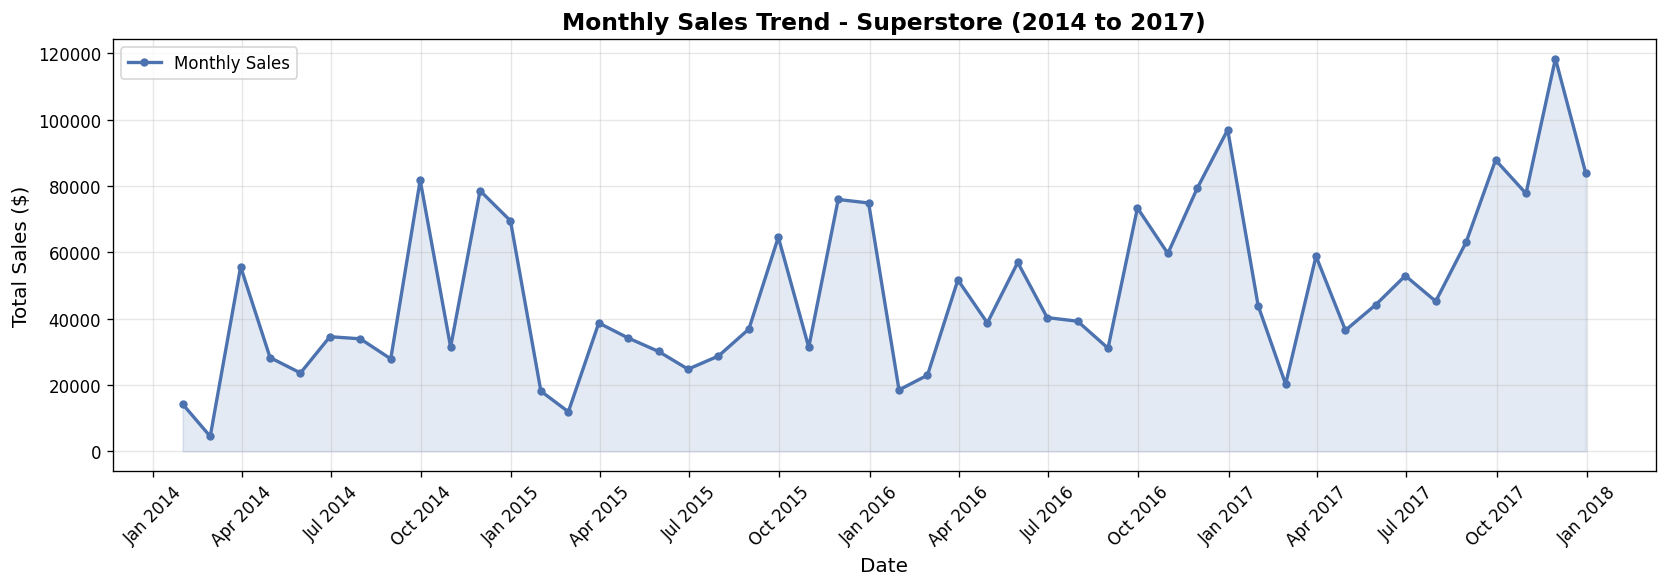

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly_sales['Date'], monthly_sales['Sales'],
        color='#4C72B0', linewidth=2, marker='o', markersize=4, label='Monthly Sales')
ax.fill_between(monthly_sales['Date'], monthly_sales['Sales'], alpha=0.15, color='#4C72B0')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Total Sales ($)', fontsize=12)
ax.set_title('Monthly Sales Trend - Superstore (2014 to 2017)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Graph 2: Sales by Category and Region

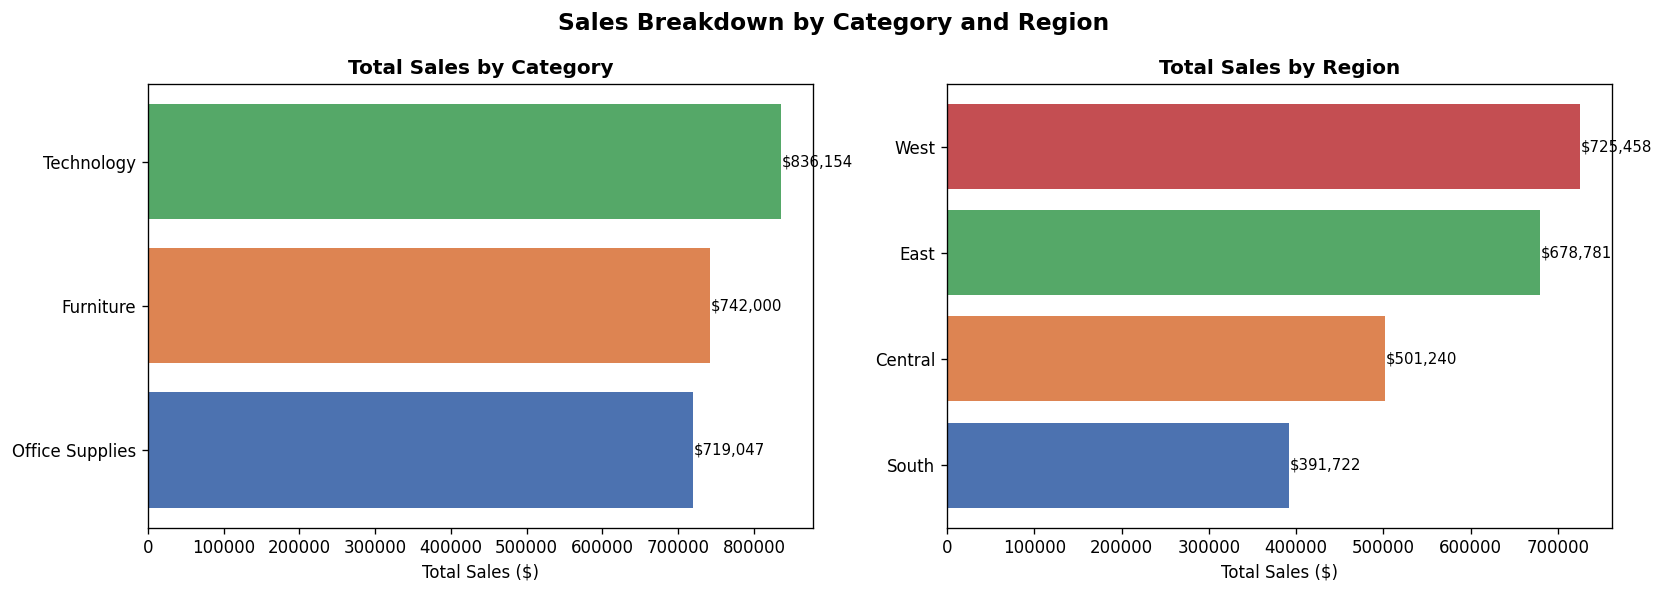

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sales by Category
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=True)
axes[0].barh(cat_sales.index, cat_sales.values, color=['#4C72B0','#DD8452','#55A868'])
for i, v in enumerate(cat_sales.values):
    axes[0].text(v + 1000, i, f'${v:,.0f}', va='center', fontsize=9)
axes[0].set_title('Total Sales by Category', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Sales ($)')

# Sales by Region
reg_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=True)
colors_r  = ['#4C72B0','#DD8452','#55A868','#C44E52']
axes[1].barh(reg_sales.index, reg_sales.values, color=colors_r)
for i, v in enumerate(reg_sales.values):
    axes[1].text(v + 1000, i, f'${v:,.0f}', va='center', fontsize=9)
axes[1].set_title('Total Sales by Region', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Sales ($)')

plt.suptitle('Sales Breakdown by Category and Region', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Graph 3: Seasonality Analysis

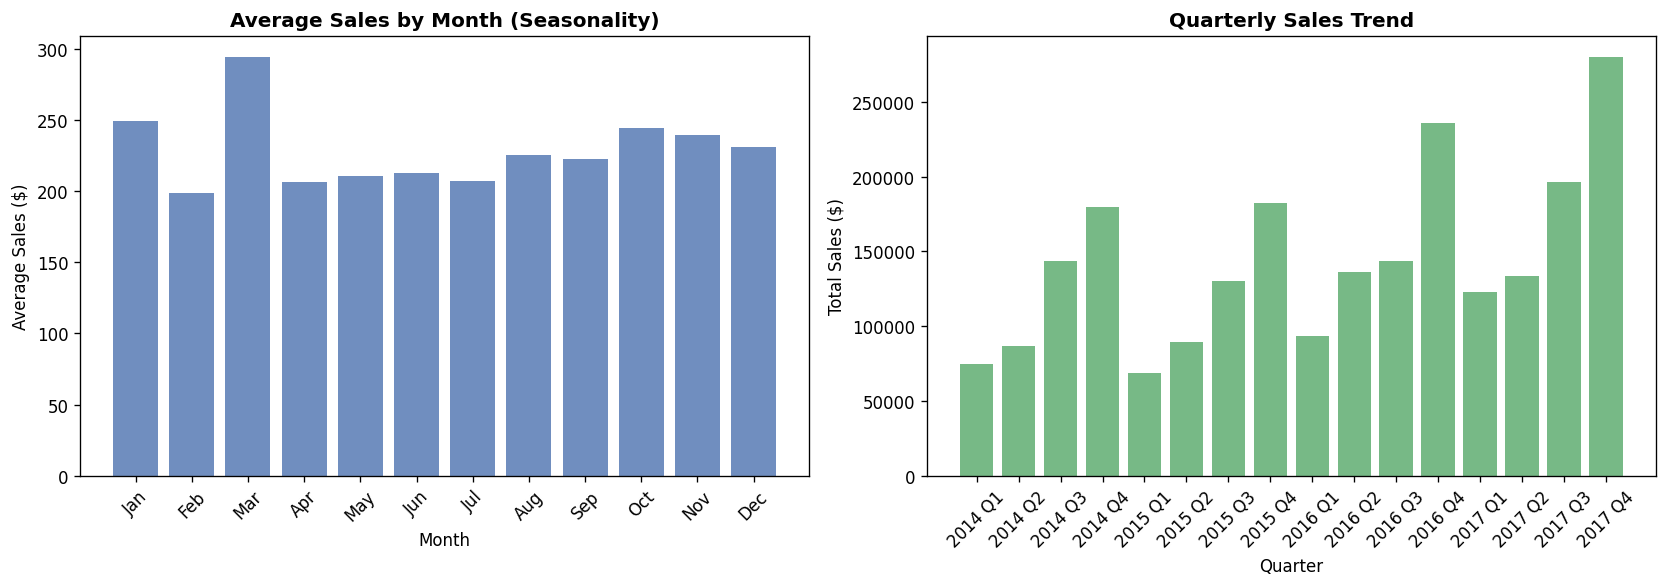

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly seasonality
month_avg = df.groupby('Month')['Sales'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[0].bar(month_names, month_avg.values, color='#4C72B0', alpha=0.8)
axes[0].set_title('Average Sales by Month (Seasonality)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Average Sales ($)')
axes[0].tick_params(axis='x', rotation=45)

# Quarterly trend
qtr_sales = df.groupby(['Year','Quarter'])['Sales'].sum().reset_index()
qtr_sales['Period'] = qtr_sales['Year'].astype(str) + ' Q' + qtr_sales['Quarter'].astype(str)
axes[1].bar(qtr_sales['Period'], qtr_sales['Sales'], color='#55A868', alpha=0.8)
axes[1].set_title('Quarterly Sales Trend', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Total Sales ($)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Graph 4: Model Performance Comparison

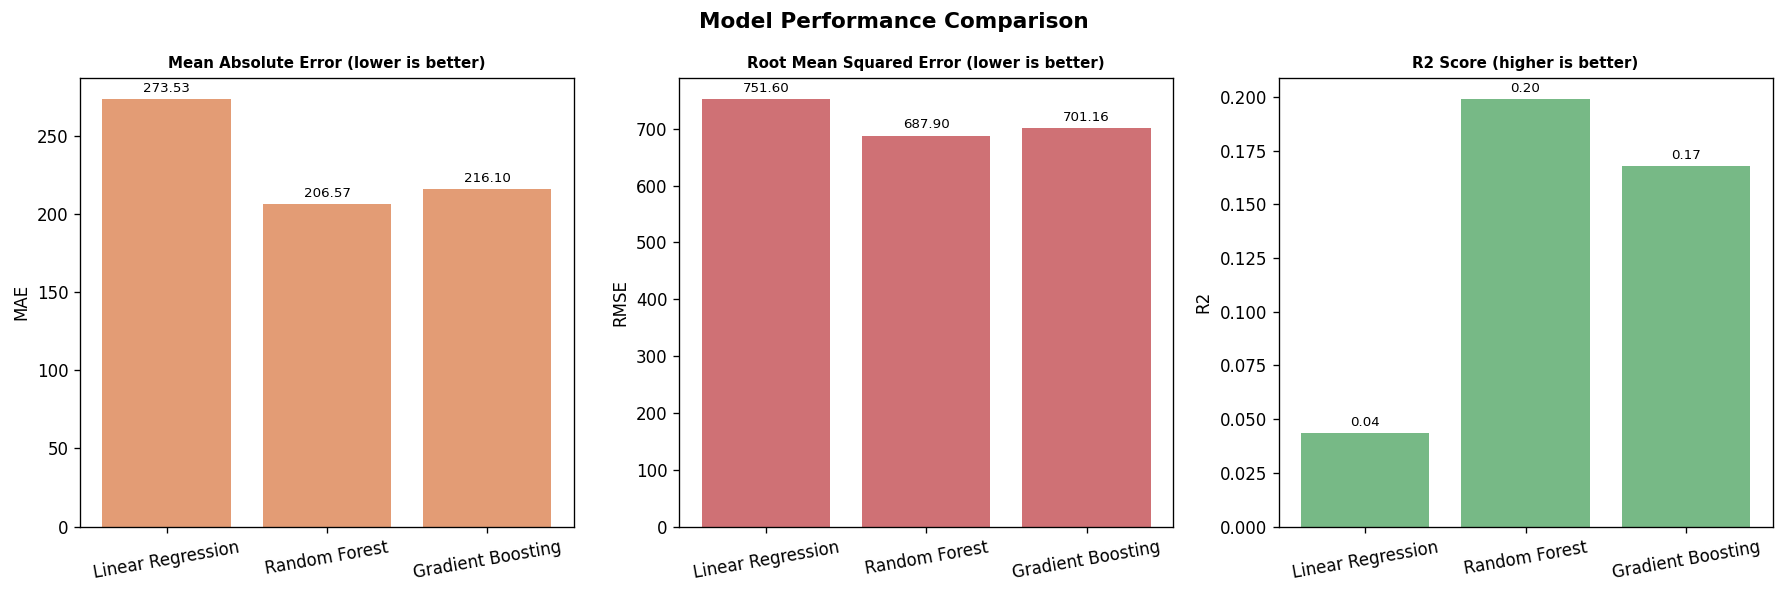

In [9]:
metrics_df = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics   = ['MAE', 'RMSE', 'R2']
colors    = ['#DD8452', '#C44E52', '#55A868']
titles    = ['Mean Absolute Error (lower is better)',
             'Root Mean Squared Error (lower is better)',
             'R2 Score (higher is better)']

for ax, metric, color, title in zip(axes, metrics, colors, titles):
    bars = ax.bar(metrics_df['Model'], metrics_df[metric], color=color, alpha=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01 * metrics_df[metric].max(),
                f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Model Performance Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Graph 5: Actual vs Predicted Sales

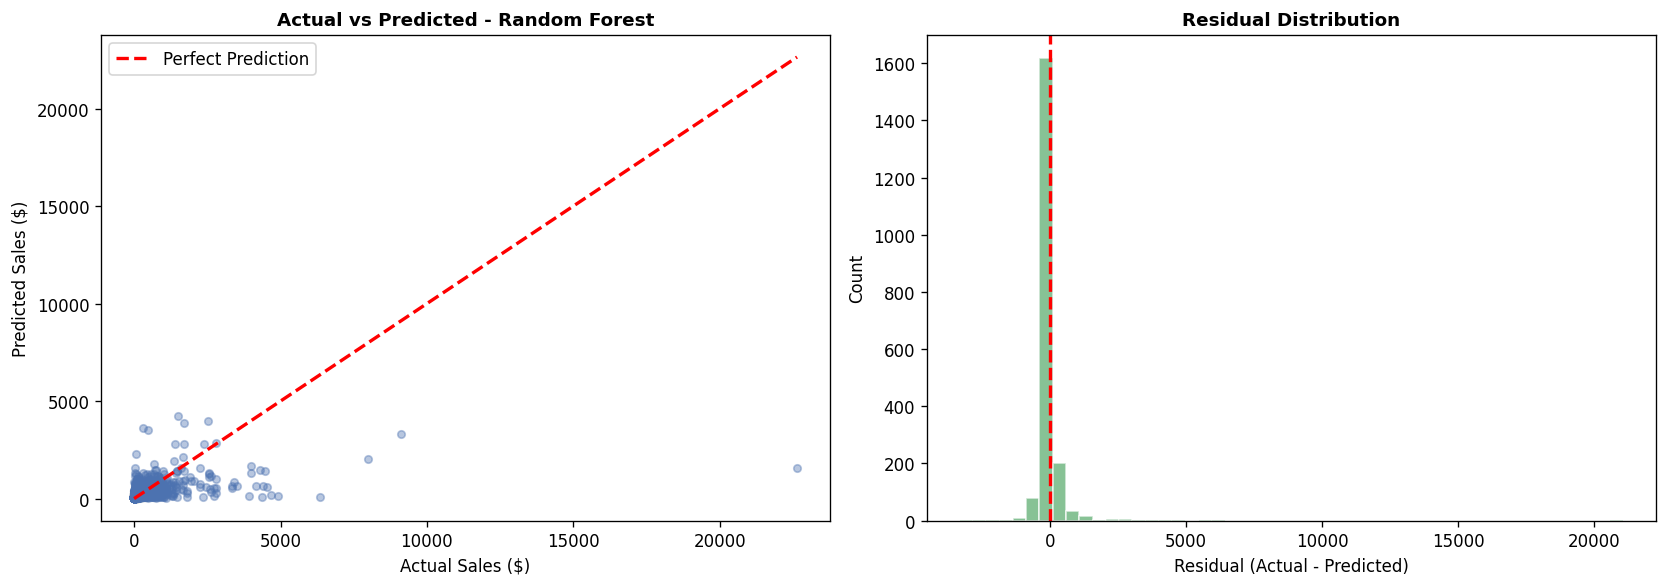

In [10]:
best_preds = predictions[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, best_preds, alpha=0.4, color='#4C72B0', s=20)
min_val = min(y_test.min(), best_preds.min())
max_val = max(y_test.max(), best_preds.max())
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Sales ($)')
axes[0].set_ylabel('Predicted Sales ($)')
axes[0].set_title(f'Actual vs Predicted - {best_name}', fontsize=11, fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test.values - best_preds
axes[1].hist(residuals, bins=50, color='#55A868', alpha=0.7, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Graph 6: 6-Month Sales Forecast

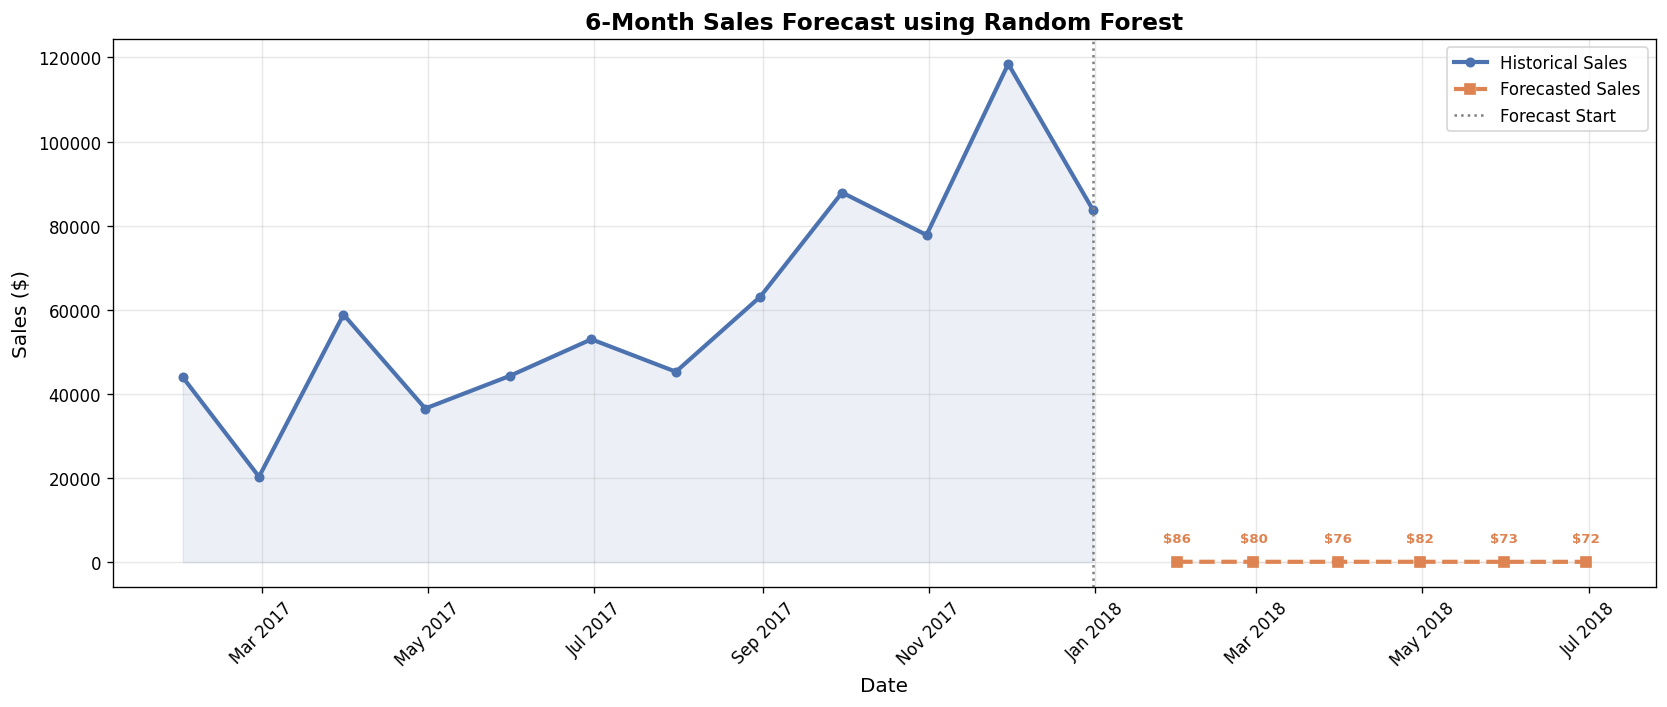

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

# Historical monthly sales (last 12 months)
hist_12 = monthly_sales.tail(12)
ax.plot(hist_12['Date'], hist_12['Sales'],
        color='#4C72B0', linewidth=2.5, marker='o', markersize=5, label='Historical Sales')
ax.fill_between(hist_12['Date'], hist_12['Sales'], alpha=0.1, color='#4C72B0')

# Forecast
ax.plot(forecast_df['Date'], forecast_df['Forecasted Sales'],
        color='#DD8452', linewidth=2.5, marker='s', markersize=6,
        linestyle='--', label='Forecasted Sales')
ax.fill_between(forecast_df['Date'], forecast_df['Forecasted Sales'], alpha=0.1, color='#DD8452')

# Annotate forecast values
for _, row in forecast_df.iterrows():
    ax.annotate(f"${row['Forecasted Sales']:,.0f}",
                xy=(row['Date'], row['Forecasted Sales']),
                xytext=(0, 12), textcoords='offset points',
                ha='center', fontsize=8, color='#DD8452', fontweight='bold')

ax.axvline(monthly_sales['Date'].max(), color='gray', linestyle=':', lw=1.5, label='Forecast Start')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Sales ($)', fontsize=12)
ax.set_title(f'6-Month Sales Forecast using {best_name}', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Graph 7: Feature Importance

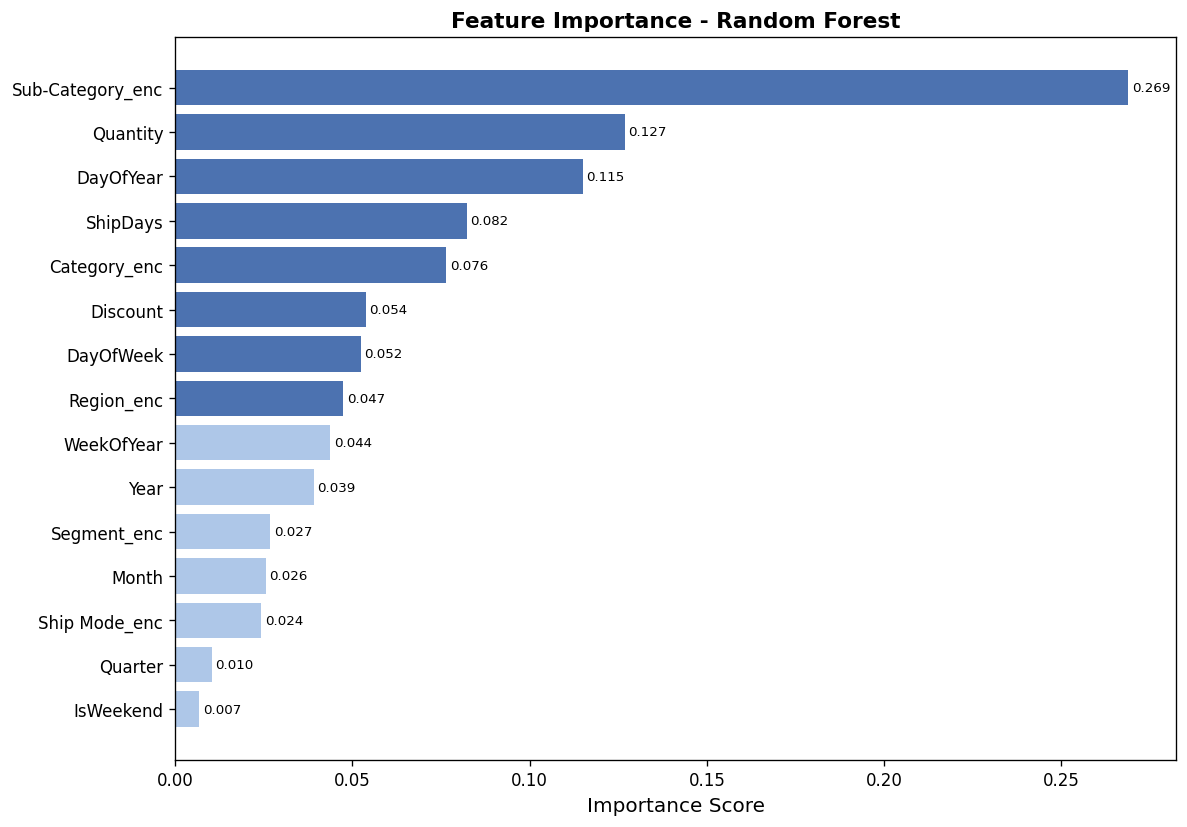

In [12]:
if best_name in ['Random Forest', 'Gradient Boosting']:
    importances = trained[best_name].feature_importances_
    feat_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors_bar = ['#4C72B0' if v >= feat_df['Importance'].median() else '#aec7e8'
                  for v in feat_df['Importance']]
    ax.barh(feat_df['Feature'], feat_df['Importance'], color=colors_bar)
    ax.set_xlabel('Importance Score', fontsize=12)
    ax.set_title(f'Feature Importance - {best_name}', fontsize=13, fontweight='bold')
    for i, (_, row) in enumerate(feat_df.iterrows()):
        ax.text(row['Importance'] + 0.001, i, f"{row['Importance']:.3f}", va='center', fontsize=8)
    plt.tight_layout()
    plt.show()

## Graph 8: Top 10 Sub-Categories by Sales

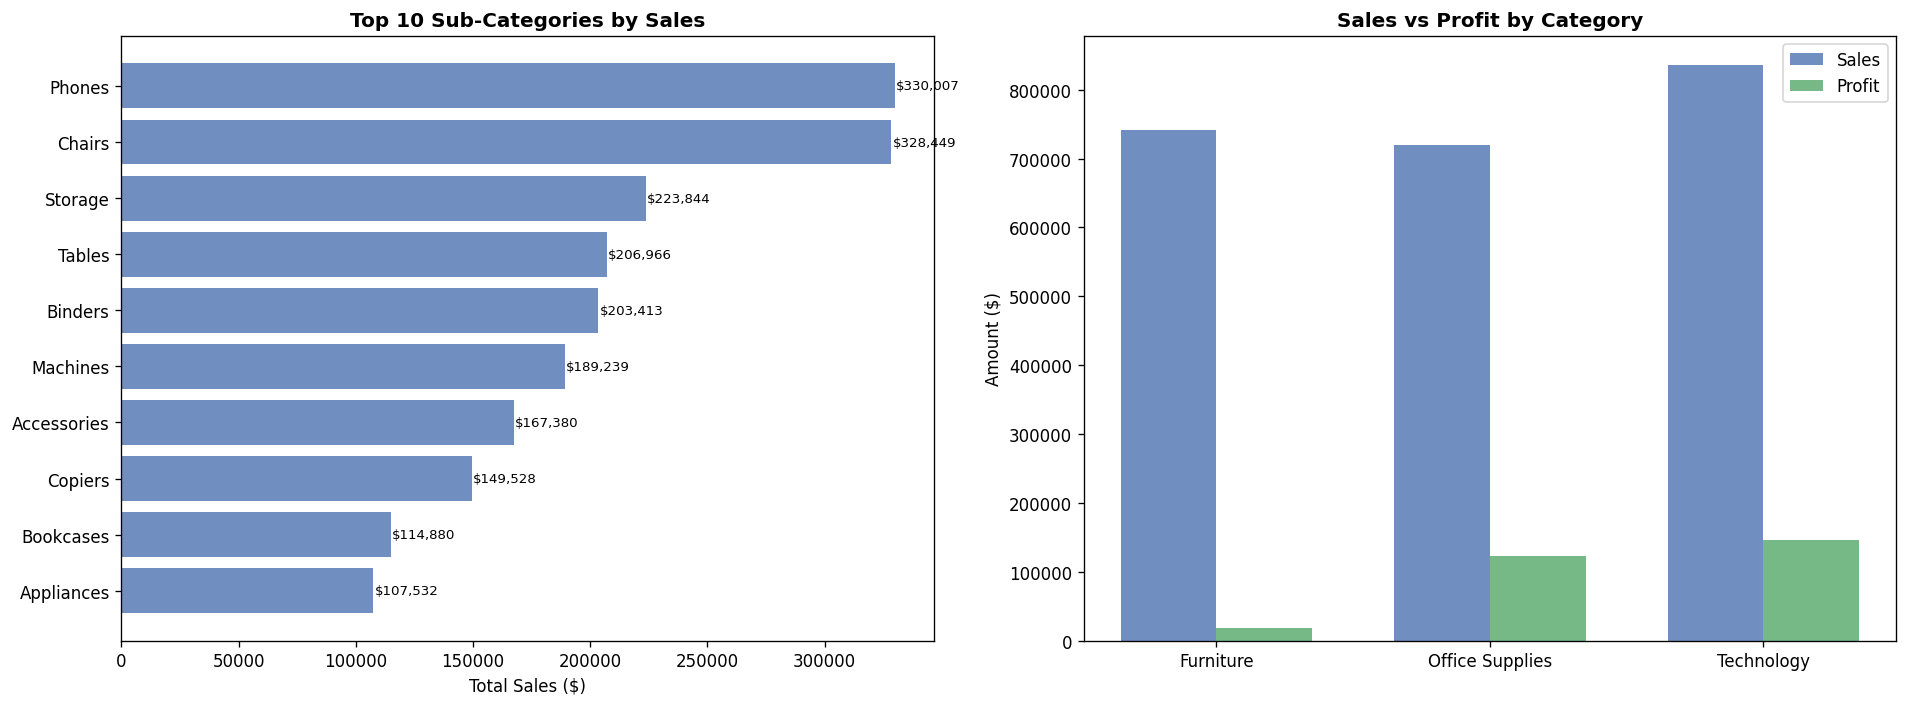

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 10 sub-categories by sales
sub_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=True).tail(10)
axes[0].barh(sub_sales.index, sub_sales.values, color='#4C72B0', alpha=0.8)
for i, v in enumerate(sub_sales.values):
    axes[0].text(v + 500, i, f'${v:,.0f}', va='center', fontsize=8)
axes[0].set_title('Top 10 Sub-Categories by Sales', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Sales ($)')

# Profit vs Sales by Category
cat_group = df.groupby('Category').agg({'Sales':'sum','Profit':'sum'}).reset_index()
x = np.arange(len(cat_group))
w = 0.35
axes[1].bar(x - w/2, cat_group['Sales'], w, label='Sales', color='#4C72B0', alpha=0.8)
axes[1].bar(x + w/2, cat_group['Profit'], w, label='Profit', color='#55A868', alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(cat_group['Category'])
axes[1].set_title('Sales vs Profit by Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Amount ($)')
axes[1].legend()

plt.tight_layout()
plt.show()

## Business Insights Summary

In [14]:
print('=' * 60)
print('  BUSINESS INSIGHTS - SUPERSTORE SALES FORECAST')
print('=' * 60)

print(f'\n1. HISTORICAL PERFORMANCE')
print(f'   Total Sales (All Years) : ${df["Sales"].sum():,.2f}')
print(f'   Total Profit            : ${df["Profit"].sum():,.2f}')
print(f'   Best Month              : {monthly_sales.loc[monthly_sales["Sales"].idxmax(), "Date"].strftime("%B %Y")} (${monthly_sales["Sales"].max():,.2f})')
print(f'   Best Category           : {df.groupby("Category")["Sales"].sum().idxmax()}')
print(f'   Best Region             : {df.groupby("Region")["Sales"].sum().idxmax()}')

print(f'\n2. MODEL PERFORMANCE')
for name, scores in results.items():
    marker = ' -- BEST' if name == best_name else ''
    print(f'   {name}{marker}')
    print(f'      MAE  : ${scores["MAE"]:,.2f}  |  RMSE: ${scores["RMSE"]:,.2f}  |  R2: {scores["R2"]:.4f}')

print(f'\n3. 6-MONTH FORECAST')
for _, row in forecast_df.iterrows():
    print(f'   {row["Date"].strftime("%B %Y")} : ${row["Forecasted Sales"]:,.2f}')
print(f'   Total Forecast : ${forecast_df["Forecasted Sales"].sum():,.2f}')

print(f'\n4. BUSINESS RECOMMENDATIONS')
print(f'   - Q4 (Oct-Dec) consistently shows highest sales - increase stock before this period')
print(f'   - Technology category drives highest revenue - prioritize supplier relationships')
print(f'   - West region leads in sales - consider expanding marketing budget here')
print(f'   - High discount rates are reducing profit margins - review discount strategy')
print('=' * 60)

  BUSINESS INSIGHTS - SUPERSTORE SALES FORECAST

1. HISTORICAL PERFORMANCE
   Total Sales (All Years) : $2,297,200.86
   Total Profit            : $286,397.02
   Best Month              : November 2017 ($118,447.82)
   Best Category           : Technology
   Best Region             : West

2. MODEL PERFORMANCE
   Linear Regression
      MAE  : $273.53  |  RMSE: $751.60  |  R2: 0.0437
   Random Forest -- BEST
      MAE  : $206.57  |  RMSE: $687.90  |  R2: 0.1989
   Gradient Boosting
      MAE  : $216.10  |  RMSE: $701.16  |  R2: 0.1677

3. 6-MONTH FORECAST
   January 2018 : $86.32
   February 2018 : $80.46
   March 2018 : $76.33
   April 2018 : $81.85
   May 2018 : $72.81
   June 2018 : $72.50
   Total Forecast : $470.28

4. BUSINESS RECOMMENDATIONS
   - Q4 (Oct-Dec) consistently shows highest sales - increase stock before this period
   - Technology category drives highest revenue - prioritize supplier relationships
   - West region leads in sales - consider expanding marketing budget 

## Final Results Summary

In [15]:
print('=' * 55)
print('  FINAL RESULTS SUMMARY')
print('=' * 55)
for name, scores in results.items():
    marker = ' -- BEST' if name == best_name else ''
    print(f'\n{name}{marker}')
    for metric, val in scores.items():
        if metric == 'R2':
            print(f'   {metric:<6}: {val:.4f}')
        else:
            print(f'   {metric:<6}: ${val:,.2f}')
print('=' * 55)

  FINAL RESULTS SUMMARY

Linear Regression
   MAE   : $273.53
   RMSE  : $751.60
   R2    : 0.0437

Random Forest -- BEST
   MAE   : $206.57
   RMSE  : $687.90
   R2    : 0.1989

Gradient Boosting
   MAE   : $216.10
   RMSE  : $701.16
   R2    : 0.1677
